## DSC 680 Week Project 1 
### Credit Card Fraud:  How it impacts consumers, trends in the current landscape, and what everyone can do to prevent fraud transactions.

Caitie Schrotberger \
Bellevue University \
DSC680-T301 Applied Data Science (2267-1) \
Sue Ashton \
June 28, 2026

In [1]:
# Import packages needed for analysis
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt

In [2]:
# Import CSV to dataframe
card_data=pd.read_csv(r'G:/My Drive/College/Caitie/DSC680/Project1/bank_fraud.csv')

# Display first 5 rows of data
card_data.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [3]:
card_data.info()
# Data is very clean.  No NULLs and fields of correct format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

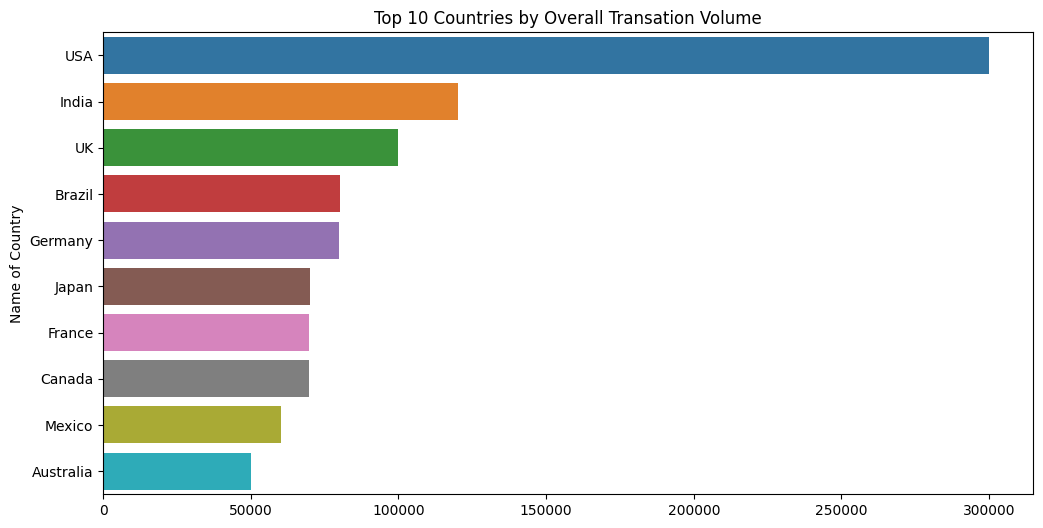

In [4]:
import seaborn as sns
country=card_data["country"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=country.values,
    y=country.index,
    hue=country.index,
    legend=False)
plt.ylabel("Name of Country")
plt.title("Top 10 Countries by Overall Transation Volume")
plt.show()

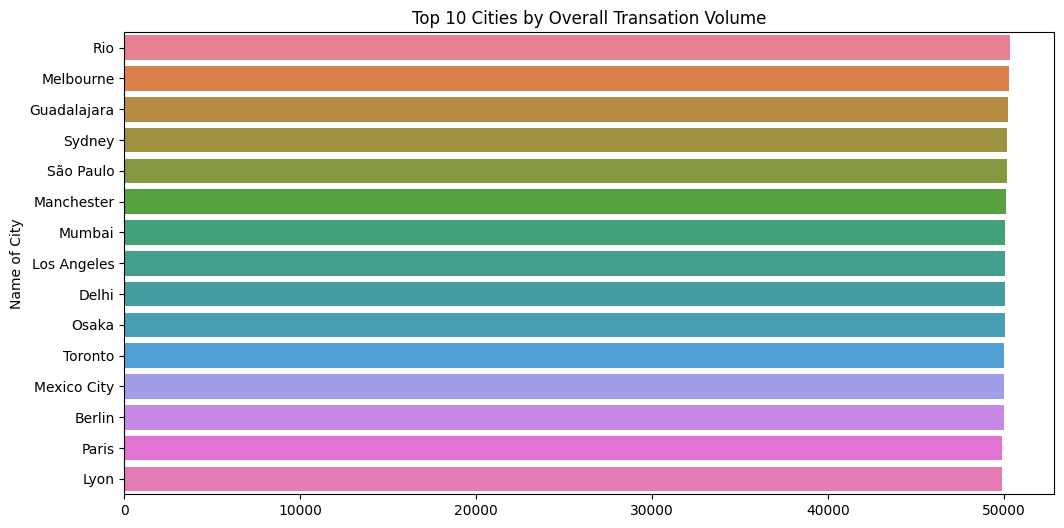

In [5]:
city=card_data["city"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=city.values,
    y=city.index,
    hue=city.index,
    legend=False)
plt.ylabel("Name of City")
plt.title("Top 10 Cities by Overall Transation Volume")
plt.show()

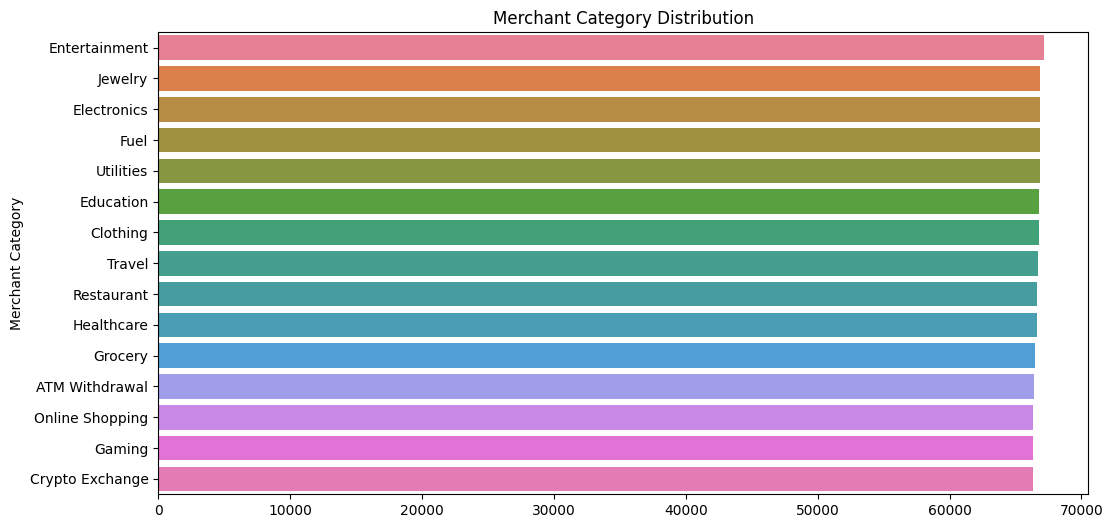

In [6]:
merchant_category=card_data["merchant_category"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=merchant_category.values,
    y=merchant_category.index,
    hue=merchant_category.index,
    legend=False)
plt.ylabel("Merchant Category")
plt.title("Merchant Category Distribution")
plt.show()

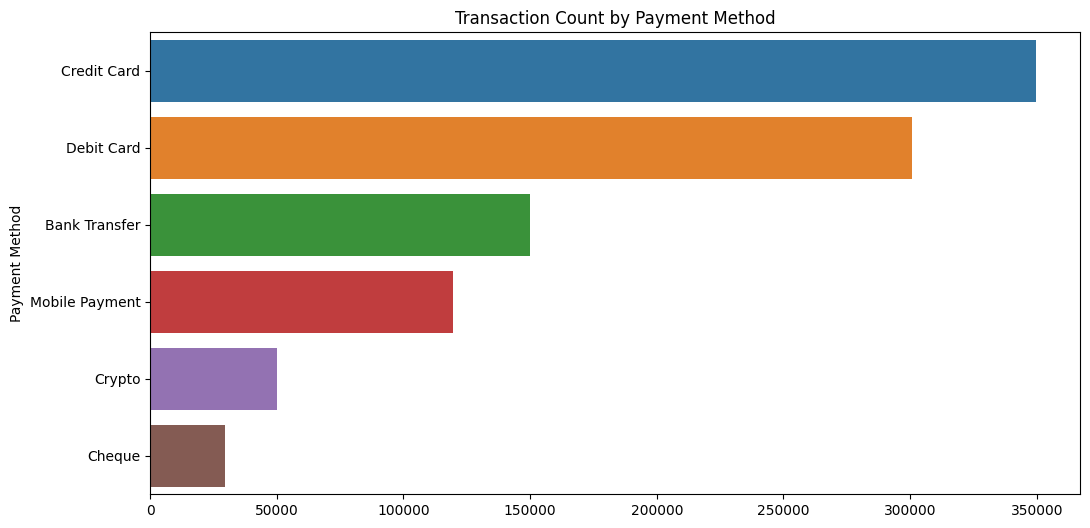

In [7]:
payment_method=card_data["payment_method"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=payment_method.values,
    y=payment_method.index,
    hue=payment_method.index,
    legend=False)
plt.ylabel("Payment Method")
plt.title("Transaction Count by Payment Method")
plt.show()

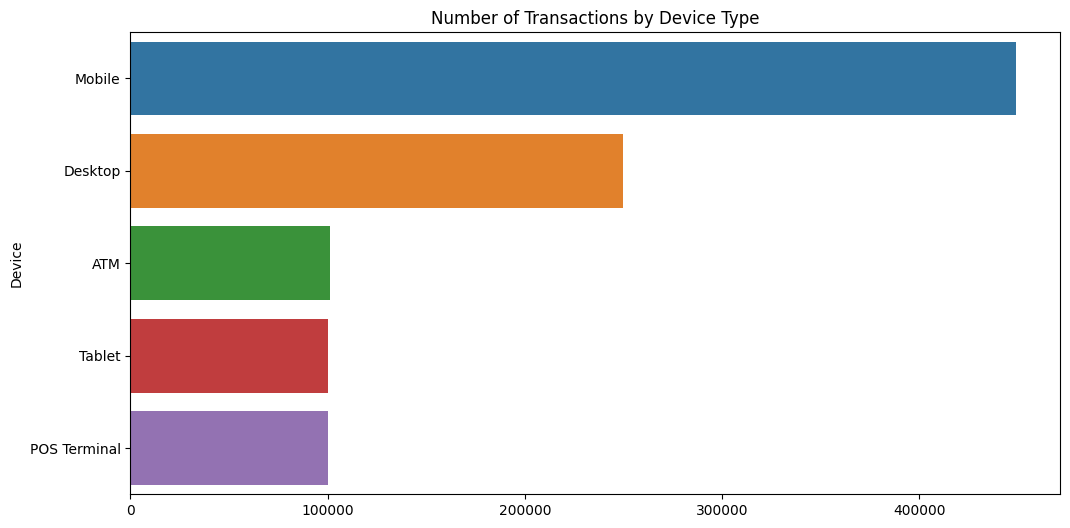

In [8]:
device_type=card_data["device_type"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=device_type.values,
    y=device_type.index,
    hue=device_type.index,
    legend=False)
plt.ylabel("Device")
plt.title("Number of Transactions by Device Type")
plt.show()

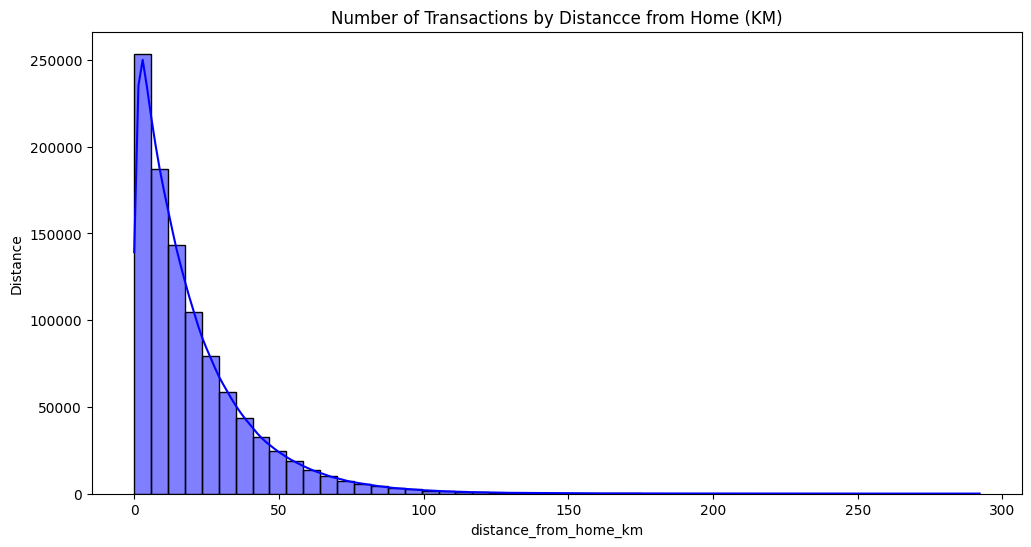

In [9]:
plt.figure(figsize=(12,6))
sns.histplot(card_data["distance_from_home_km"],
    bins=50,
    kde=True,
    color="blue")
plt.ylabel("Distance")
plt.title("Number of Transactions by Distancce from Home (KM)")
plt.show()

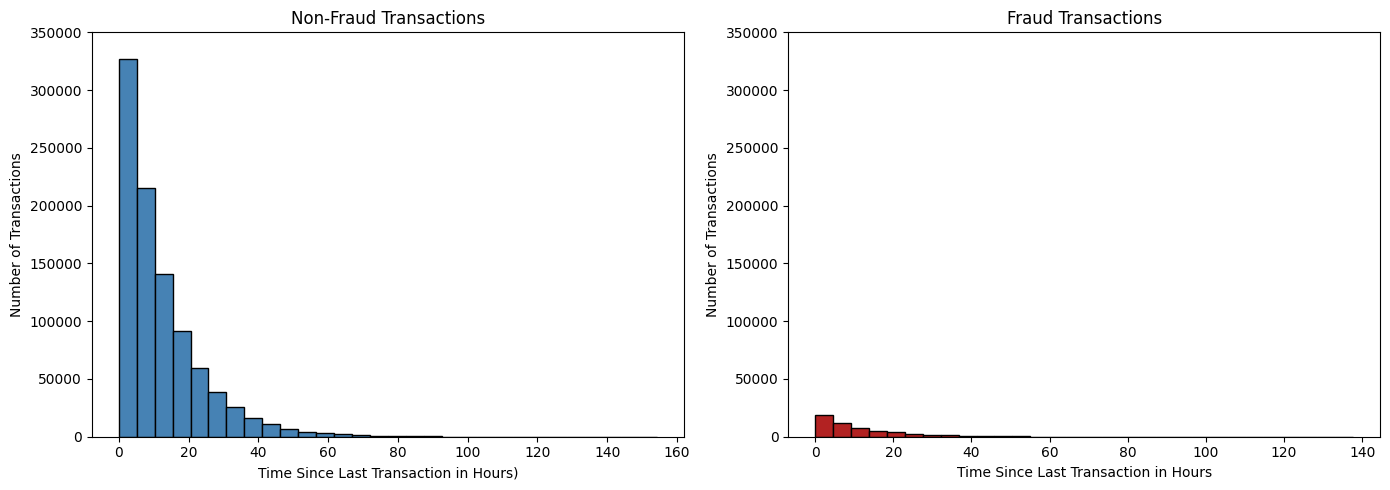

In [10]:
# Evaluate a few of the metrics to understand the data
num_bins = 30
fraud_0 = card_data[card_data['is_fraud'] == 0]['time_since_last_txn_hrs']
fraud_1 = card_data[card_data['is_fraud'] == 1]['time_since_last_txn_hrs']
plt.figure(figsize=(14, 5))
# Histogram for non-fraud
plt.subplot(1, 2, 1)
plt.hist(fraud_0, bins=num_bins, color='steelblue', edgecolor='black')
plt.title("Non‑Fraud Transactions")
plt.xlabel("Time Since Last Transaction in Hours)")
plt.ylabel("Number of Transactions")
plt.ylim(0, 350000)
# Histogram for fraud
plt.subplot(1, 2, 2)
plt.hist(fraud_1, bins=num_bins, color='firebrick', edgecolor='black')
plt.title("Fraud Transactions")
plt.xlabel("Time Since Last Transaction in Hours")
plt.ylabel("Number of Transactions")
plt.ylim(0, 350000)

plt.tight_layout()
plt.show()

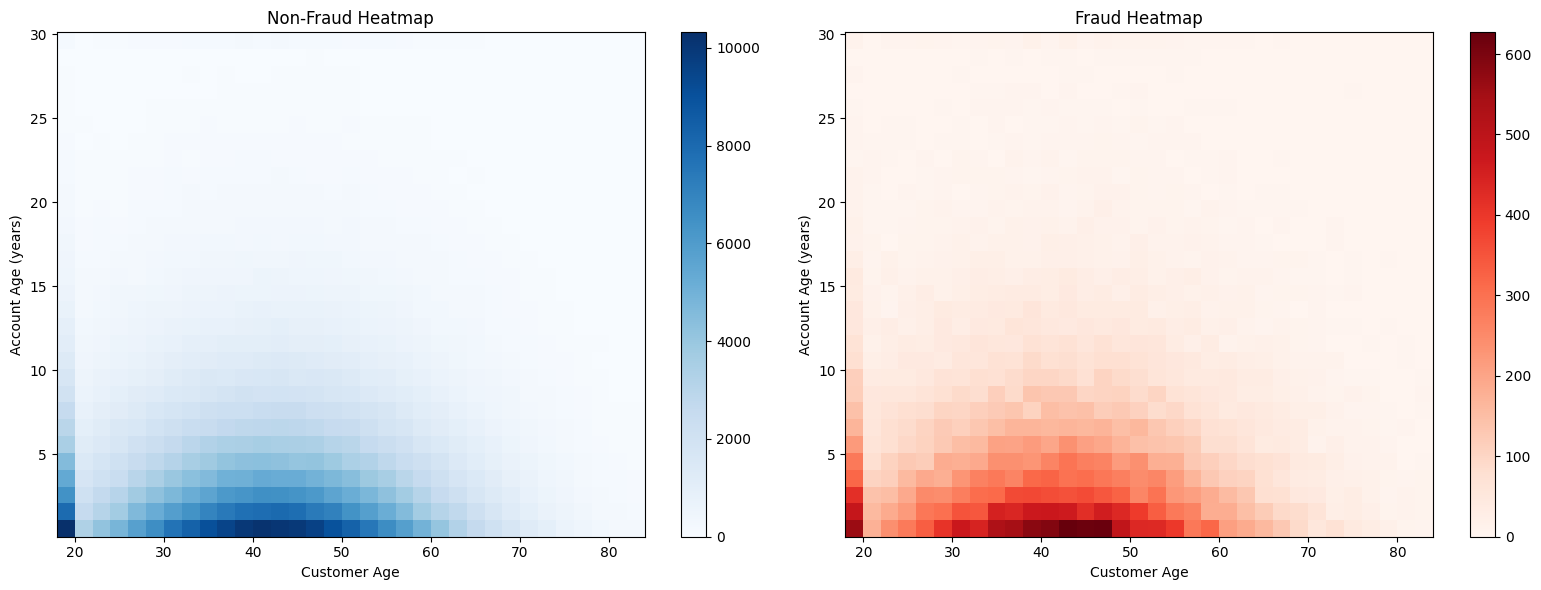

In [11]:
fraud_0_2 = card_data[card_data['is_fraud'] == 0]
fraud_1_2 = card_data[card_data['is_fraud'] == 1]
age_bins = np.arange(18, 86, 2)
acct_bins = np.arange(card_data['account_age_years'].min(),
                      card_data['account_age_years'].max() + 1, 1)

# Compute 2D histograms
H0, xedges, yedges = np.histogram2d(
    fraud_0_2['customer_age'], fraud_0_2['account_age_years'],
    bins=[age_bins, acct_bins]
)

H1, _, _ = np.histogram2d(
    fraud_1_2['customer_age'], fraud_1_2['account_age_years'],
    bins=[age_bins, acct_bins]
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
heat_0 = axes[0].imshow(
    H0.T,
    origin='lower',
    aspect='auto',
    cmap='Blues',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]  # <-- FIX
)
axes[0].set_title("Non‑Fraud Heatmap")
axes[0].set_xlabel("Customer Age")
axes[0].set_ylabel("Account Age (years)")
fig.colorbar(heat_0, ax=axes[0])
heat_1 = axes[1].imshow(
    H1.T,
    origin='lower',
    aspect='auto',
    cmap='Reds',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]  # <-- FIX
)
axes[1].set_title("Fraud Heatmap")
axes[1].set_xlabel("Customer Age")
axes[1].set_ylabel("Account Age (years)")
fig.colorbar(heat_1, ax=axes[1])
plt.tight_layout()
plt.show()

In [12]:
# Create data frame without fields model can't evalute
drop_cols = [
    'transaction_id', 
    'customer_id',
    'transaction_date',
    'transaction_time',
    'country',
    'city']
fraud_model = card_data.drop(columns=drop_cols)

In [13]:
# One Hot Encode categorical fields.  
cat_cols = fraud_model.select_dtypes(include=['object']).columns
fraud_encoded = pd.get_dummies(fraud_model, columns=cat_cols, drop_first=True)

### Logistic Regression

In [14]:
from sklearn.model_selection import train_test_split
x_fraud = fraud_encoded
x_fraud = x_fraud.drop(['is_fraud'], axis=1)
y_fraud = fraud_encoded['is_fraud']
X_train, X_test, Y_train, Y_test = train_test_split(x_fraud, y_fraud, test_size=0.2, random_state = 1)

In [15]:
# Scale numerical fiedls and run model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=0
    )) ])
model_logreg = pipe.fit(X_train, Y_train)
Y_pred_logreg = model_logreg.predict(X_test)

In [16]:
# Assess accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, Y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.984155


In [17]:
# Get the precision, recall, and F1-score for the test set predictions.
# Precision
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, Y_train, scoring="precision", cv=5)

array([0.87467456, 0.86153488, 0.85581555, 0.87380812, 0.86270612])

In [18]:
# Create a confusion matrix for the test set predictions.
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cnf_matrix = metrics.confusion_matrix(Y_test, Y_pred_logreg)
cnf_matrix

array([[187566,   1374],
       [  1795,   9265]])

In [19]:
# Recall
cross_val_score(pipe, X_train, Y_train, scoring="recall", cv=5)

array([0.83618056, 0.83697251, 0.84410001, 0.83980088, 0.83459667])

In [20]:
# F1
cross_val_score(pipe, X_train, Y_train, scoring="f1", cv=5)

array([0.85499451, 0.84907609, 0.84991741, 0.85646706, 0.84841863])

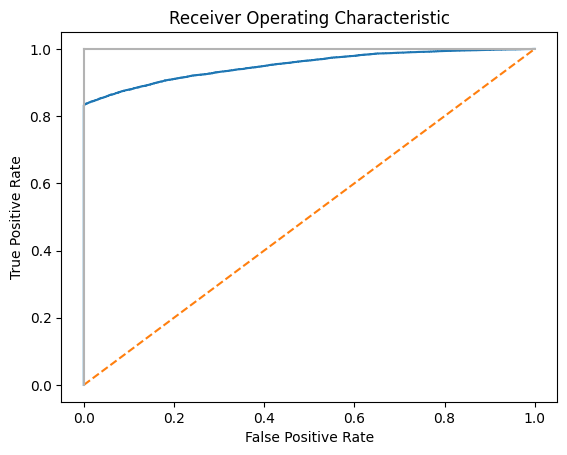

In [21]:
#Create a ROC curve for the test set
from sklearn.metrics import roc_curve, roc_auc_score
y_proba = model_logreg.predict_proba(X_test)[:, 1]
false_positive_rate, true_positive_rate, threshold = roc_curve(Y_test,y_proba)

# Plot ROC curve
plt.title("Receiver Operating Characteristic")
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()